métriques : sur 50 runs
- mean and std reward
- longueur moyenne de l'épisode
- distance parcourue
- % épisodes terminés sans collision
- distribution des actions

In [3]:
import gymnasium as gym
from copy import deepcopy
import numpy as np
import torch
import torch.nn as nn

import highway_env

from stable_baselines3 import DQN

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## Config

In [39]:
SHARED_CORE_ENV_ID = "highway-v0"

SHARED_CORE_CONFIG = {
    "observation": {
        "type": "Kinematics",
        "vehicles_count": 10,
        "features": ["presence", "x", "y", "vx", "vy"],
        "absolute": False,
        "normalize": True,
        "clip": True,
        "see_behind": True,
        "observe_intentions": False,
    },
    "action": {
        "type": "DiscreteMetaAction",
        "target_speeds": [20, 25, 30],
    },
    "lanes_count": 4,
    "vehicles_count": 45,
    "controlled_vehicles": 1,
    "initial_lane_id": None,
    "duration": 30,
    "ego_spacing": 2,
    "vehicles_density": 1.0,
    "collision_reward": -1.5,
    "right_lane_reward": 0.0,
    "high_speed_reward": 0.7,
    "lane_change_reward": -0.02,
    "reward_speed_range": [22, 30],
    "normalize_reward": True,
    "offroad_terminal": True,
}

EVAL_SEEDS = list(range(50))  # for reproducible 

ACTION_LABELS = {0: "LANE_LEFT", 1: "IDLE", 2: "LANE_RIGHT", 3: "FASTER", 4: "SLOWER"}

def make_env(config=None, render_mode=None):
    env = gym.make(SHARED_CORE_ENV_ID, render_mode=render_mode)
    if config:
        env.unwrapped.config.update(config)
    return env

env = make_env(SHARED_CORE_CONFIG)
obs, _ = env.reset()
print("Observation shape :", obs.shape)
print("Action space      :", env.action_space)
print("Flattened obs size:", obs.flatten().shape[0])


Observation shape : (10, 5)
Action space      : Discrete(5)
Flattened obs size: 50


## Agents

### Random agent

In [41]:
def get_action_random(obs):
    return env.action_space.sample()

### DQN

In [8]:
class QNet(nn.Module):
    def __init__(self, obs_size, n_actions, hidden_size=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions),
        )

    def forward(self, x):
        return self.net(x)


In [ ]:
CHECKPOINT_PATH = "dqn_highway_checkpoint.pt"  # adjust if needed

env_tmp = make_env(SHARED_CORE_CONFIG)
obs, _ = env_tmp.reset()
OBS_SIZE  = obs.flatten().shape[0]
N_ACTIONS = env_tmp.action_space.n

custom_dqn = QNet(OBS_SIZE, N_ACTIONS).to(device)
custom_dqn.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
custom_dqn.eval()

QNet(
  (net): Sequential(
    (0): Linear(in_features=50, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=5, bias=True)
  )
)

In [10]:
def get_action_custom(obs):
    state_t = torch.FloatTensor(obs.flatten()).unsqueeze(0).to(device)
    with torch.no_grad():
        q_values = custom_dqn(state_t)
    return q_values.argmax(dim=1).item()

### DQN stable baselines

In [11]:
sb_dqn = DQN.load("dqn_stable_baseline_longer_episodes")

In [26]:
def get_action_sb(obs):
    action, _states = sb_dqn.predict(obs, deterministic=True)
    return action

## Métriques

In [31]:
def eval_agent(get_action, CONFIG, EVAL_SEEDS):
    """
    Monte Carlo evaluation using fixed seeds.
    """
    n_sim = len(EVAL_SEEDS)

    env = make_env(CONFIG)
    env_copy = deepcopy(env)

    episode_rewards = np.zeros(n_sim)
    episode_lengths = np.zeros(n_sim)
    episode_distances = np.zeros(n_sim)
    episode_collisions = np.zeros(n_sim, dtype=bool)
    episode_actions = []

    for i, seed in enumerate(EVAL_SEEDS):
        print(f"Simulating episode {i} with seed {seed}")

        state, _ = env_copy.reset(seed=seed)
        reward_sum = 0
        length = 0
        distance = 0
        actions = []
        done = False
        while not done: 
            action = get_action(state)
            actions.append(action)
            state, reward, terminated, truncated, _ = env_copy.step(action)
            reward_sum += reward
            length+=1
            dt = 1 / env_copy.unwrapped.config["simulation_frequency"]
            speed = env_copy.unwrapped.vehicle.speed
            distance += speed * dt
            done = terminated or truncated
        if terminated:
            episode_collisions[i] = True
        episode_rewards[i] = reward_sum
        episode_lengths[i] = length
        episode_distances[i] = distance
        episode_actions.append(actions)
    return episode_rewards, episode_lengths, episode_distances, episode_collisions, episode_actions

In [42]:
EVAL_SEEDS = list(range(10))
eval_random = eval_agent(get_action_random, SHARED_CORE_CONFIG, EVAL_SEEDS)
eval_custom = eval_agent(get_action_custom, SHARED_CORE_CONFIG, EVAL_SEEDS)
eval_sb = eval_agent(get_action_sb, SHARED_CORE_CONFIG, EVAL_SEEDS)

Simulating episode 0 with seed 0
Simulating episode 1 with seed 1
Simulating episode 2 with seed 2
Simulating episode 3 with seed 3
Simulating episode 4 with seed 4
Simulating episode 5 with seed 5
Simulating episode 6 with seed 6
Simulating episode 7 with seed 7
Simulating episode 8 with seed 8
Simulating episode 9 with seed 9
Simulating episode 0 with seed 0
Simulating episode 1 with seed 1
Simulating episode 2 with seed 2
Simulating episode 3 with seed 3
Simulating episode 4 with seed 4
Simulating episode 5 with seed 5
Simulating episode 6 with seed 6
Simulating episode 7 with seed 7
Simulating episode 8 with seed 8
Simulating episode 9 with seed 9
Simulating episode 0 with seed 0
Simulating episode 1 with seed 1
Simulating episode 2 with seed 2
Simulating episode 3 with seed 3
Simulating episode 4 with seed 4
Simulating episode 5 with seed 5
Simulating episode 6 with seed 6
Simulating episode 7 with seed 7
Simulating episode 8 with seed 8
Simulating episode 9 with seed 9


In [33]:
def print_eval_metrics(eval_output, label="Custom DQN"):
    """
    Print performance metrics from eval_agent output.
    """
    rewards, lengths, distances, collisions, actions = eval_output

    # Reward
    reward_mean = rewards.mean()
    reward_std = rewards.std()

    # Longueur épisode
    length_mean = lengths.mean()
    length_std = lengths.std()

    # Distance
    distance_mean = distances.mean()
    distance_std = distances.std()

    # Sécurité
    success_rate = 100 * (~collisions).mean()  # % sans collision
    collision_rate = 100 * collisions.mean()

    print(f"Evaluation Results for network {label}")
    print(f"Reward: mean = {reward_mean:.3f}, std = {reward_std:.3f}")
    print(f"Length: mean = {length_mean:.2f}, std = {length_std:.2f}")
    print(f"Distance: mean = {distance_mean:.2f}, std = {distance_std:.2f}")
    print(f"No collision: {success_rate:.1f}%")
    print(f"Collision: {collision_rate:.1f}%")

In [43]:
print_eval_metrics(eval_random, "Random Policy")
print("\n")
print_eval_metrics(eval_custom, "Custom DQN")
print("\n")
print_eval_metrics(eval_sb, "Stable baselines")

Evaluation Results for network Random Policy
Reward: mean = 8.285, std = 5.427
Length: mean = 10.90, std = 7.06
Distance: mean = 17.74, std = 10.72
No collision: 10.0%
Collision: 90.0%


Evaluation Results for network Custom DQN
Reward: mean = 18.024, std = 5.729
Length: mean = 25.70, std = 8.67
Distance: mean = 35.85, std = 10.65
No collision: 80.0%
Collision: 20.0%


Evaluation Results for network Stable baselines
Reward: mean = 14.251, std = 6.447
Length: mean = 18.90, std = 8.99
Distance: mean = 29.40, std = 12.40
No collision: 30.0%
Collision: 70.0%


In [37]:
import numpy as np
import matplotlib.pyplot as plt

def plot_action_distribution(eval_output, n_actions, action_labels=None, title="Action distribution"):
    episode_rewards, episode_lengths, episode_distances, episode_collisions, episode_actions = eval_output

    all_actions = np.concatenate(episode_actions)
    counts = np.bincount(all_actions, minlength=n_actions)
    if action_labels is None:
        labels = [str(i) for i in range(n_actions)]
    else:
        labels = [action_labels.get(i, str(i)) for i in range(n_actions)]

    x = np.arange(n_actions)

    plt.figure(figsize=(6, 4))
    plt.bar(x, counts, alpha=0.8)
    plt.xticks(x, labels, rotation=15)
    plt.ylabel("Count")
    plt.title(title)
    plt.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

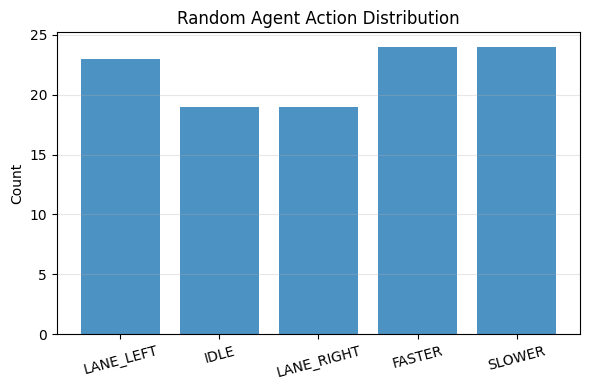

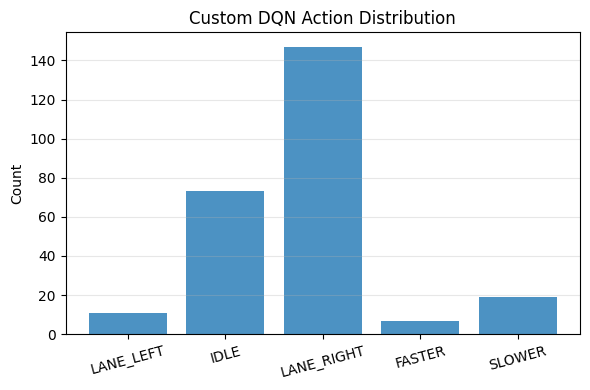

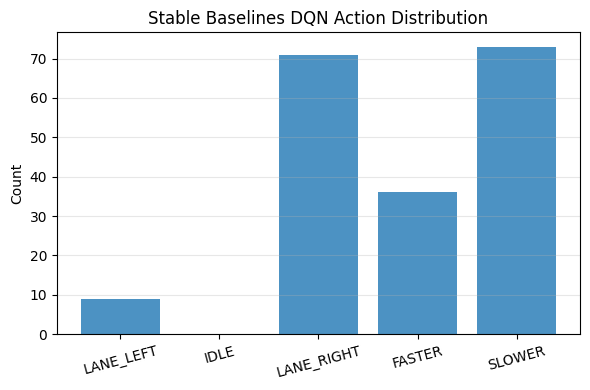

In [44]:
plot_action_distribution(eval_random, N_ACTIONS, action_labels=ACTION_LABELS, title="Random Agent Action Distribution")
plot_action_distribution(eval_custom, N_ACTIONS, action_labels=ACTION_LABELS, title="Custom DQN Action Distribution")
plot_action_distribution(eval_sb, N_ACTIONS, action_labels=ACTION_LABELS, title="Stable Baselines DQN Action Distribution")

## Analyse des comportements

Sur un run :
- évolution du reward
- distribution des actions
- vitesse 


In [45]:
import numpy as np
import matplotlib.pyplot as plt

def compare_agents(get_actions, agent_names, CONFIG, seed, n_actions, action_labels=None):

    episodes_data = []

    for get_action in get_actions:
        env = make_env(CONFIG)
        state, _ = env.reset(seed=seed)

        rewards = []
        actions = []
        speeds = []

        done = False
        while not done:
            action = get_action(state)
            actions.append(action)

            state, reward, terminated, truncated, _ = env.step(action)

            rewards.append(reward)
            speeds.append(env.unwrapped.vehicle.speed)

            done = terminated or truncated

        episodes_data.append({
            "rewards": np.array(rewards),
            "actions": np.array(actions),
            "speeds": np.array(speeds),
        })

    n_agents = len(episodes_data)
    colors = plt.cm.tab10.colors

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    ax = axes[0]
    for i, data in enumerate(episodes_data):
        ax.plot(np.cumsum(data["rewards"]), lw=2, color=colors[i], label=agent_names[i])

    ax.set_xlabel("Step")
    ax.set_ylabel("Cumulative Reward")
    ax.set_title("Cumulative reward")
    ax.legend()
    ax.grid(alpha=0.3)

    ax = axes[1]
    for i, data in enumerate(episodes_data):
        ax.plot(data["speeds"], lw=2, color=colors[i], label=agent_names[i])

    ax.set_xlabel("Step")
    ax.set_ylabel("Speed")
    ax.set_title("Speed over time")
    ax.legend()
    ax.grid(alpha=0.3)

    ax = axes[2]
    x = np.arange(n_actions)
    width = 0.8 / n_agents

    if action_labels is None:
        labels = [str(i) for i in range(n_actions)]
    else:
        labels = [action_labels.get(i, str(i)) for i in range(n_actions)]

    for i, data in enumerate(episodes_data):
        counts = np.bincount(data["actions"], minlength=n_actions)

        ax.bar(x+i*width-(n_agents-1)*width/2, counts, width, label=agent_names[i], alpha=0.8, color=colors[i])

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15)
    ax.set_ylabel("Count")
    ax.set_title("Action distribution")
    ax.legend()
    ax.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

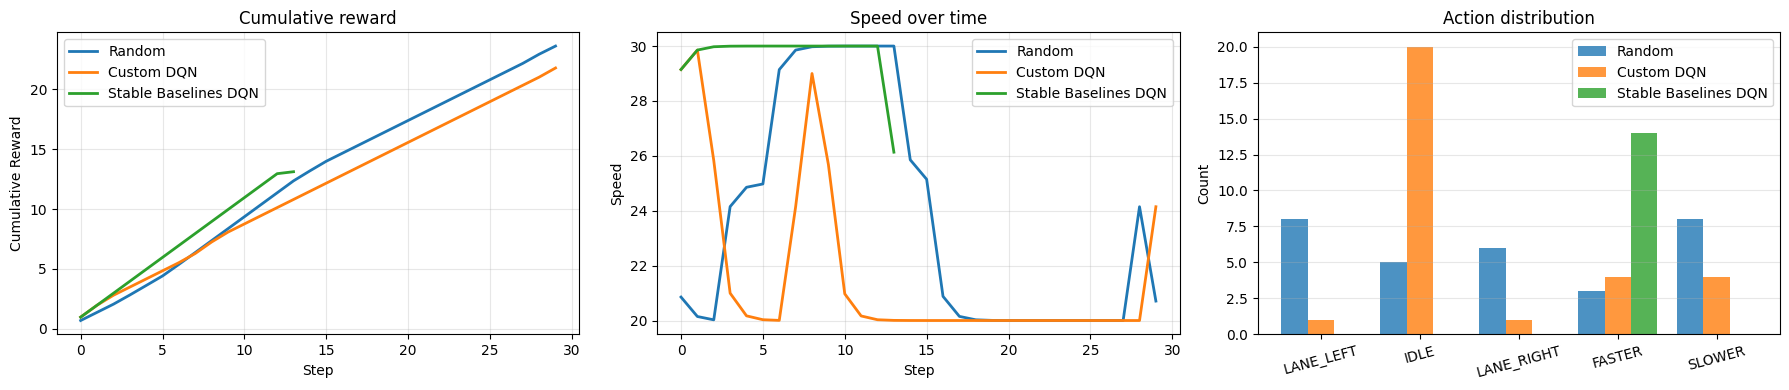

In [46]:
compare_agents(
    get_actions=[get_action_random, get_action_custom, get_action_sb],
    agent_names=["Random", "Custom DQN", "Stable Baselines DQN"],
    CONFIG=SHARED_CORE_CONFIG,
    seed=42,
    n_actions=N_ACTIONS,
    action_labels=ACTION_LABELS
)